# 06. 하이퍼파라미터 비교 실험

**작성일**: 2026-09-18

**목표**: 지금까지 여러 노트북에 "다음에 비교해볼 것"으로 이월해둔 질문들을 실제 실험으로 확인한다.

1. (02번에서 이월) 베이스라인 임베딩을 **랜덤 초기화 vs 02번에서 학습한 Word2Vec으로 초기화**했을 때 차이가 있는가?
2. 베이스라인 **learning rate**를 바꾸면 어떻게 달라지는가?
3. (04번에서 이월) KoBART가 빠르게 과적합하는 경향을 **learning rate/스케줄**로 완화할 수 있는가?
4. (PLAN.md 이월) **KE-T5**로 같은 방식으로 파인튜닝하면 KoBART와 어떻게 다른가?

각 실험은 "다른 조건은 고정하고 하나만 바꾼다"는 통제 실험 원칙을 지킨다. 정식 정량 평가(BLEU/ROUGE 등, 전체 test set)는 07번에서 진행하고, 여기서는 validation loss와 생성 예시로 경향을 확인한다.

In [1]:
# 2026-09-18: 공통 라이브러리/데이터 준비
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm
from gensim.models import Word2Vec

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_df = pd.read_csv('../dataset/processed/train.csv')
val_df = pd.read_csv('../dataset/processed/val.csv')
test_df = pd.read_csv('../dataset/processed/test.csv')
sample_test = test_df.sample(8, random_state=42)  # 03/04/05번과 동일한 질문

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Part A. 베이스라인 하이퍼파라미터 비교
03/04번과 동일한 모델 구조·데이터 파이프라인을 재사용한다. 세 configuration을 공정하게 비교하기 위해 셋 다 같은 학습 예산(`MAX_EPOCHS=60, PATIENCE=6`)을 준다 — 04번(최대 150 epoch)보다 예산을 줄인 것은 순수히 실험 시간 절약이 목적이며, 04번에서 이미 "30 epoch 이후 개선 폭이 완만해진다"는 것을 확인했으므로 세 configuration을 상대 비교하는 데는 60 epoch 예산으로 충분하다고 판단했다.

In [2]:
# 2026-09-18: 베이스라인 데이터 파이프라인 (03/04번과 동일)
sp = spm.SentencePieceProcessor(model_file='../dataset/processed/chatbot_bpe.model')
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
VOCAB_SIZE = sp.get_piece_size()
MAX_LEN = 16


def encode_text(text: str, max_len: int = MAX_LEN):
    ids = sp.encode(text, out_type=int)[: max_len - 2]
    return [BOS_ID] + ids + [EOS_ID]


class ChatbotDataset(Dataset):
    def __init__(self, df):
        self.questions = df['Q'].tolist()
        self.answers = df['A'].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        return (
            torch.tensor(encode_text(self.questions[idx]), dtype=torch.long),
            torch.tensor(encode_text(self.answers[idx]), dtype=torch.long),
        )


def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    return (
        pad_sequence(src_batch, batch_first=True, padding_value=PAD_ID),
        pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_ID),
    )


BATCH_SIZE = 64
train_loader = DataLoader(ChatbotDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(ChatbotDataset(val_df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [3]:
# 2026-09-18: 베이스라인 모델 구조 (03/04번과 동일)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.d_model = d_model

    def forward(self, tokens):
        return self.embedding(tokens) * math.sqrt(self.d_model)


class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward, dropout):
        super().__init__()
        self.tok_emb = TokenEmbedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers, num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True,
        )
        self.generator = nn.Linear(d_model, vocab_size)
        self.generator.weight = self.tok_emb.embedding.weight

    def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, memory_key_padding_mask):
        src_emb = self.pos_enc(self.tok_emb(src))
        tgt_emb = self.pos_enc(self.tok_emb(tgt))
        outs = self.transformer(
            src_emb, tgt_emb, src_mask=src_mask, tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask, tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(self.pos_enc(self.tok_emb(src)), src_mask)

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(self.pos_enc(self.tok_emb(tgt)), memory, tgt_mask)


def generate_square_subsequent_mask(sz, device):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, 0.0)
    return mask


def create_mask(src, tgt, device):
    src_seq_len, tgt_seq_len = src.size(1), tgt.size(1)
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len, device)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=device)
    return src_mask, tgt_mask, (src == PAD_ID), (tgt == PAD_ID)


@torch.no_grad()
def greedy_decode(model, src_text, max_len=MAX_LEN):
    model.eval()
    src = torch.tensor(encode_text(src_text), dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros((src.size(1), src.size(1)), device=device)
    memory = model.encode(src, src_mask)
    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    for _ in range(max_len - 1):
        tgt_mask = generate_square_subsequent_mask(ys.size(1), device)
        out = model.decode(ys, memory, tgt_mask)
        next_word = model.generator(out[:, -1]).argmax(dim=-1).item()
        ys = torch.cat([ys, torch.tensor([[next_word]], device=device)], dim=1)
        if next_word == EOS_ID:
            break
    ids = ys.squeeze(0).tolist()[1:]
    return sp.decode(ids[:-1] if ids and ids[-1] == EOS_ID else ids)

### A-1. Word2Vec 임베딩 초기화 준비

02번에서 학습한 Word2Vec은 **형태소(Okt) 단위** vocab이고, 베이스라인 모델은 **BPE subword** vocab(8000개)을 쓴다 — 둘은 토큰화 단위 자체가 다르므로 index가 대응되지 않는다. 그래서:
1. 각 BPE subword piece에서 SentencePiece의 단어-시작 표시(`▁`)를 제거한 문자열이 Word2Vec vocab에 **그대로** 존재하는 경우에만 그 벡터를 가져온다(부분적 커버리지만 기대할 수 있음 — 아래에서 실측).
2. Word2Vec은 100차원, 베이스라인은 256차원이라 차원이 다르다. 고정된 랜덤 투사(random projection) 행렬(100→256)을 한 번 만들어 곱해서 차원을 맞춘다(학습 가능한 파라미터가 아니라 초기화 시점에만 쓰는 고정 변환).
3. 매칭되지 않는 나머지 BPE 토큰은 기존처럼 랜덤 초기화를 그대로 둔다.

In [4]:
# 2026-09-18: BPE vocab -> Word2Vec 벡터 매칭률 측정 및 초기화 행렬 생성
w2v = Word2Vec.load('../dataset/processed/word2vec.model')

D_MODEL = 256
rng = np.random.default_rng(42)
projection = rng.normal(scale=1.0 / np.sqrt(100), size=(100, D_MODEL)).astype(np.float32)  # (100 -> 256) 고정 랜덤 투사

matched_ids, matched_vecs = [], []
for idx in range(VOCAB_SIZE):
    piece = sp.id_to_piece(idx).replace('\u2581', '')  # '▁' 제거
    if piece in w2v.wv:
        matched_ids.append(idx)
        matched_vecs.append(w2v.wv[piece] @ projection)

coverage = len(matched_ids) / VOCAB_SIZE
print(f'BPE vocab {VOCAB_SIZE}개 중 Word2Vec과 매칭된 토큰: {len(matched_ids)}개 (커버리지 {coverage:.1%})')

matched_ids_t = torch.tensor(matched_ids, dtype=torch.long)
matched_vecs_t = torch.tensor(np.array(matched_vecs), dtype=torch.float32)


def make_model(embedding_init='random'):
    torch.manual_seed(SEED)
    model = Seq2SeqTransformer(VOCAB_SIZE, D_MODEL, 8, 3, 3, 512, 0.1).to(device)
    if embedding_init == 'word2vec':
        with torch.no_grad():
            model.tok_emb.embedding.weight[matched_ids_t] = matched_vecs_t.to(device)
    return model

BPE vocab 8000개 중 Word2Vec과 매칭된 토큰: 4272개 (커버리지 53.4%)


In [5]:
# 2026-09-18: 학습/평가 함수 (03/04번과 동일한 로직을 함수로 재사용)
def train_one_config(model, lr, max_epochs=60, patience=6, label=''):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.98), eps=1e-9)
    best_val, patience_cnt = float('inf'), 0
    history = {'train_loss': [], 'val_loss': []}
    ckpt_path = Path(f'../checkpoints/hparam_{label}.pt')

    for epoch in range(1, max_epochs + 1):
        model.train()
        total = 0.0
        for src, tgt in train_loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input, tgt_out = tgt[:, :-1], tgt[:, 1:]
            src_mask, tgt_mask, src_pad, tgt_pad = create_mask(src, tgt_input, device)
            logits = model(src, tgt_input, src_mask, tgt_mask, src_pad, tgt_pad, src_pad)
            optimizer.zero_grad()
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total += loss.item()
        train_loss = total / len(train_loader)

        model.eval()
        total = 0.0
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                tgt_input, tgt_out = tgt[:, :-1], tgt[:, 1:]
                src_mask, tgt_mask, src_pad, tgt_pad = create_mask(src, tgt_input, device)
                logits = model(src, tgt_input, src_mask, tgt_mask, src_pad, tgt_pad, src_pad)
                total += criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1)).item()
        val_loss = total / len(val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val:
            best_val, patience_cnt = val_loss, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, history, best_val

In [6]:
# 2026-09-18: A0 (control) - random init, lr=1e-4 / A1 - word2vec init, lr=1e-4 / A2 - random init, lr=3e-4
baseline_results = {}

model_a0 = make_model('random')
model_a0, hist_a0, best_a0 = train_one_config(model_a0, lr=1e-4, label='A0_random_lr1e-4')
baseline_results['A0 random-init, lr=1e-4'] = (model_a0, hist_a0, best_a0)
print(f'A0 완료 | best val_loss={best_a0:.4f} | epochs={len(hist_a0["train_loss"])}')

C:\Users\KDS-11\Documents\nlp_project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(
C:\Users\KDS-11\Documents\nlp_project\.venv\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


A0 완료 | best val_loss=5.9659 | epochs=60


In [7]:
model_a1 = make_model('word2vec')
model_a1, hist_a1, best_a1 = train_one_config(model_a1, lr=1e-4, label='A1_word2vec_lr1e-4')
baseline_results['A1 word2vec-init, lr=1e-4'] = (model_a1, hist_a1, best_a1)
print(f'A1 완료 | best val_loss={best_a1:.4f} | epochs={len(hist_a1["train_loss"])}')

A1 완료 | best val_loss=5.8173 | epochs=60


In [8]:
model_a2 = make_model('random')
model_a2, hist_a2, best_a2 = train_one_config(model_a2, lr=3e-4, label='A2_random_lr3e-4')
baseline_results['A2 random-init, lr=3e-4'] = (model_a2, hist_a2, best_a2)
print(f'A2 완료 | best val_loss={best_a2:.4f} | epochs={len(hist_a2["train_loss"])}')

A2 완료 | best val_loss=5.6799 | epochs=48


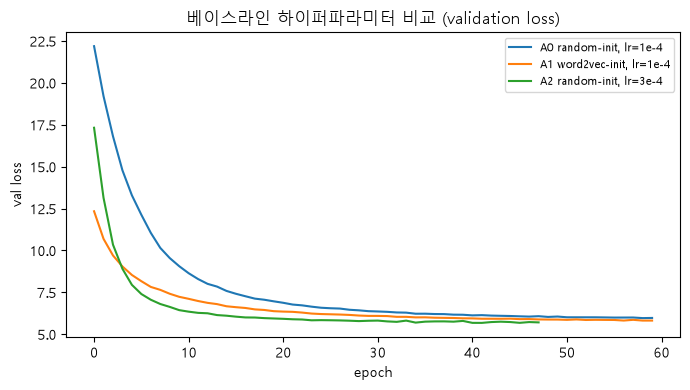

,config,best_val_loss,epochs_run
0,"A0 random-init, lr=1e-4",5.965858,60
1,"A1 word2vec-init, lr=1e-4",5.817336,60
2,"A2 random-init, lr=3e-4",5.679855,48


In [9]:
# 2026-09-18: Part A 결과 비교 - 학습곡선
fig, ax = plt.subplots(figsize=(7, 4))
for name, (_, hist, _) in baseline_results.items():
    ax.plot(hist['val_loss'], label=name)
ax.set_xlabel('epoch')
ax.set_ylabel('val loss')
ax.set_title('베이스라인 하이퍼파라미터 비교 (validation loss)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../dataset/processed/hparam_baseline_comparison.png', dpi=120)
plt.show()

summary_a = pd.DataFrame([
    {'config': name, 'best_val_loss': best, 'epochs_run': len(hist['train_loss'])}
    for name, (_, hist, best) in baseline_results.items()
])
summary_a

In [10]:
# 2026-09-18: Part A - 생성 예시 비교 (동일 질문)
for _, row in sample_test.iterrows():
    print(f"Q: {row['Q']}")
    for name, (model, _, _) in baseline_results.items():
        print(f"  [{name}] {greedy_decode(model, row['Q'])}")
    print()

Q: 모르는 사람 만나는거 너무 스트레스야
  [A0 random-init, lr=1e-4] 사람 괜찮아요.
  [A1 word2vec-init, lr=1e-4] 그런 사람 말은 신경쓰지 마세요.
  [A2 random-init, lr=3e-4] 신나는 노래를 들어보세요.

Q: 정장 한 벌 필요할 듯
  [A0 random-init, lr=1e-4] 잘 지내고 있을 거예요.
  [A1 word2vec-init, lr=1e-4] 많이 사랑했나봐요.
  [A2 random-init, lr=3e-4] 그런 사람 합리 합리 합리 합리 합리 합리 합리 더 사면 아니라 아니라 아니라 아니라

Q: 베터리 겨우 15%야
  [A0 random-init, lr=1e-4] 사람 만날 수 있을 거예요.


  [A1 word2vec-init, lr=1e-4] 시간은 시간은 시간은 시간은 시간은 시간은 시간은 시간은 시간은 시간은 더 많이 소개시켜.
  [A2 random-init, lr=3e-4] 미리 충전하세요.

Q: 오늘 생각보다 춥네
  [A0 random-init, lr=1e-4] 마음을 전해보세요.
  [A1 word2vec-init, lr=1e-4] 세상에네요.
  [A2 random-init, lr=3e-4] 마음 감기 조심하세요.

Q: 이젠 진짜 진짜 안녕
  [A0 random-init, lr=1e-4] 좋은 인연이 거기까지인가봐요.
  [A1 word2vec-init, lr=1e-4] 이별의 이별의 이별의 이별의 이별의 이별의 이별의 이별의 이별의 이별의 상처를.
  [A2 random-init, lr=3e-4] 안녕하세요.

Q: 맥주 한 잔 어때?
  [A0 random-init, lr=1e-4] 같이 가보세요.
  [A1 word2vec-init, lr=1e-4] 저도 같이 같이 같이 같이요.


  [A2 random-init, lr=3e-4] 한 잔 같이 자신에 대해 말고도 돼요.

Q: 드디어 천일
  [A0 random-init, lr=1e-4] 좋은 생각이에요.
  [A1 word2vec-init, lr=1e-4] 좋은 생각이에요.
  [A2 random-init, lr=3e-4] 해보세요.

Q: 청첩장을 찍는 날이 오다니
  [A0 random-init, lr=1e-4] 좋은 생각이에요.
  [A1 word2vec-init, lr=1e-4] 맘고생 많았어요.
  [A2 random-init, lr=3e-4] 좋은 스타일.



**Part A 결론은 위 표/생성 예시 실행 결과를 보고 아래 '종합 요약' 절에서 정리한다.**

---

## Part B. KoBART 하이퍼파라미터 비교
04번(lr=5e-5 고정, val_loss 2.79, 4epoch째부터 과적합 시작)을 기준(B0)으로 삼고, 두 가지를 새로 시도한다: (B1) lr을 더 낮춰서(2e-5) 사전학습 지식을 덜 건드리게 하기, (B2) 동일 lr(5e-5)에 **linear warmup + decay 스케줄**을 추가해 학습 초반 급격한 업데이트를 완화하기. 두 가지 모두 파인튜닝에서 과적합/불안정을 줄이는 표준적인 방법이다.

In [11]:
# 2026-09-18: KoBART 공통 준비
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_linear_schedule_with_warmup

kobart_tokenizer = AutoTokenizer.from_pretrained('gogamza/kobart-base-v2')
KOBART_MAX_LEN = 16


class Seq2SeqTextDataset(Dataset):
    def __init__(self, df):
        self.questions = df['Q'].tolist()
        self.answers = df['A'].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        return self.questions[idx], self.answers[idx]


def make_collate_fn(tokenizer, max_len):
    def collate_fn(batch):
        questions, answers = zip(*batch)
        model_inputs = tokenizer(list(questions), padding=True, truncation=True, max_length=max_len, return_tensors='pt')
        labels = tokenizer(text_target=list(answers), padding=True, truncation=True, max_length=max_len, return_tensors='pt')['input_ids']
        labels[labels == tokenizer.pad_token_id] = -100
        model_inputs['labels'] = labels
        return model_inputs
    return collate_fn


KOBART_BATCH_SIZE = 16
kobart_collate = make_collate_fn(kobart_tokenizer, KOBART_MAX_LEN)
kobart_train_loader = DataLoader(Seq2SeqTextDataset(train_df), batch_size=KOBART_BATCH_SIZE, shuffle=True, collate_fn=kobart_collate)
kobart_val_loader = DataLoader(Seq2SeqTextDataset(val_df), batch_size=KOBART_BATCH_SIZE, shuffle=False, collate_fn=kobart_collate)

C:\Users\KDS-11\Documents\nlp_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# 2026-09-18: 재사용 가능한 seq2seq LM 파인튜닝 함수 (KoBART/KE-T5 공통)
# mixed precision: fp16(GradScaler)은 T5 계열에서 NaN loss로 발산하는 것으로 잘 알려진 문제가 있다
# (T5는 원래 TPU에서 bf16으로 사전학습되어 활성값의 동적 범위가 커서 fp16의 좁은 지수 범위를 넘어서기 쉽다).
# 그래서 fp16 대신 bf16 autocast를 사용한다 - bf16은 fp32와 지수 범위가 같아 오버플로우 위험이 없고,
# GradScaler 없이도(스케일링 불필요) 안정적으로 학습된다. 이 GPU(RTX 5060, Blackwell)는 bf16을 지원한다.
def finetune_seq2seq_lm(model_name, train_loader, val_loader, lr, use_schedule=False, max_epochs=7, patience=3, label=''):
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    use_amp = device.type == 'cuda'

    scheduler = None
    if use_schedule:
        total_steps = len(train_loader) * max_epochs
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

    ckpt_dir = Path(f'../checkpoints/hparam_{label}')
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    best_val, patience_cnt = float('inf'), 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        total = 0.0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    loss = model(**batch).loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            else:
                loss = model(**batch).loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            if scheduler is not None:
                scheduler.step()
            total += loss.item()
        train_loss = total / len(train_loader)

        model.eval()
        total = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                total += model(**batch).loss.item()
        val_loss = total / len(val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f'[{label}] epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}')

        if val_loss < best_val:
            best_val, patience_cnt = val_loss, 0
            model.save_pretrained(ckpt_dir)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'  -> epoch {epoch}에서 조기 종료 (best val_loss={best_val:.4f})')
                break

    model = AutoModelForSeq2SeqLM.from_pretrained(ckpt_dir).to(device)
    return model, history, best_val

In [13]:
# 2026-09-18: B1 - lr=2e-5 (04번의 5e-5보다 보수적인 lr)
kobart_b1, hist_b1, best_b1 = finetune_seq2seq_lm(
    'gogamza/kobart-base-v2', kobart_train_loader, kobart_val_loader,
    lr=2e-5, use_schedule=False, label='kobart_B1_lr2e-5'
)


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]


Loading weights:  17%|█▋        | 44/259 [00:00<00:00, 436.77it/s]


Loading weights:  34%|███▍      | 88/259 [00:00<00:00, 386.13it/s]


Loading weights: 100%|██████████| 259/259 [00:00<00:00, 808.41it/s]

[kobart_B1_lr2e-5] epoch 01 | train 4.3802 | val 3.7889


...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.71it/s]


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]


Loading weights:  25%|██▌       | 66/260 [00:00<00:00, 632.96it/s]


Loading weights:  50%|█████     | 130/260 [00:00<00:00, 422.81it/s]


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 874.20it/s]

In [14]:
# 2026-09-18: B2 - lr=5e-5 + linear warmup/decay 스케줄 (04번과 동일 lr, 스케줄만 추가)
kobart_b2, hist_b2, best_b2 = finetune_seq2seq_lm(
    'gogamza/kobart-base-v2', kobart_train_loader, kobart_val_loader,
    lr=5e-5, use_schedule=True, label='kobart_B2_lr5e-5_warmup'
)


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]


Loading weights:  20%|██        | 52/259 [00:00<00:00, 485.09it/s]


Loading weights:  39%|███▉      | 101/259 [00:00<00:00, 450.50it/s]


Loading weights: 100%|██████████| 259/259 [00:00<00:00, 805.89it/s]

[kobart_B2_lr5e-5_warmup] epoch 01 | train 4.7932 | val 3.7360


...

[kobart_B2_lr5e-5_warmup] epoch 07 | train 0.7994 | val 3.1580
  -> epoch 7에서 조기 종료 (best val_loss=3.1209)



Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]


Loading weights:  16%|█▌        | 42/260 [00:00<00:00, 409.88it/s]


Loading weights:  32%|███▏      | 83/260 [00:00<00:00, 271.02it/s]


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 867.57it/s]

In [15]:
# 2026-09-18: Part B 결과 비교 (B0 = 04번 결과를 그대로 인용)
kobart_results = {
    'B0 (04번) lr=5e-5, 고정': {'best_val_loss': 2.7939, 'epochs_run': 7},
    'B1 lr=2e-5, 고정': {'best_val_loss': best_b1, 'epochs_run': len(hist_b1['train_loss'])},
    'B2 lr=5e-5, warmup+decay': {'best_val_loss': best_b2, 'epochs_run': len(hist_b2['train_loss'])},
}
pd.DataFrame(kobart_results).T

,best_val_loss,epochs_run
"B0 (04번) lr=5e-5, 고정",2.793900,7.0
"B1 lr=2e-5, 고정",3.199281,7.0
"B2 lr=5e-5, warmup+decay",3.120892,7.0


In [16]:
# 2026-09-18: Part B - 생성 예시 비교
@torch.no_grad()
def hf_generate(model, tokenizer, question, max_len, **gen_kwargs):
    inputs = tokenizer(question, return_tensors='pt').to(device)
    out = model.generate(**inputs, max_length=max_len, **gen_kwargs)
    return tokenizer.decode(out[0], skip_special_tokens=True)


for _, row in sample_test.iterrows():
    print(f"Q: {row['Q']}")
    print(f"  [B1 lr=2e-5]        {hf_generate(kobart_b1, kobart_tokenizer, row['Q'], KOBART_MAX_LEN, num_beams=5, no_repeat_ngram_size=3)}")
    print(f"  [B2 lr=5e-5+warmup] {hf_generate(kobart_b2, kobart_tokenizer, row['Q'], KOBART_MAX_LEN, num_beams=5, no_repeat_ngram_size=3)}")
    print()

Q: 모르는 사람 만나는거 너무 스트레스야


  [B1 lr=2e-5]        그런 사람 만나지 마세요. 자신을 더 사랑해주세요. 자신을 사랑해주
  [B2 lr=5e-5+warmup] 그런 사람 만나지 마세요. 자신을 더 사랑해주세요. 자신을 사랑해주

Q: 정장 한 벌 필요할 듯


  [B1 lr=2e-5]        장갑 한 벌이면 충분해요. 차분히 기다려보세요.
  [B2 lr=5e-5+warmup] 정리가 잘 되길 바랄게요. 자연스러운 현상이에요. 자연

Q: 베터리 겨우 15%야


  [B1 lr=2e-5]        미리 충전 충전해드리고 싶네요. 알아차려보세요.
  [B2 lr=5e-5+warmup] 소액결제를 줄여보세요. 조금이라도 절약할 수 있을 거예요!

Q: 오늘 생각보다 춥네


  [B1 lr=2e-5]        생각보다 감기 조심하세요. 오늘 강추위예요. 기분
  [B2 lr=5e-5+warmup] 감기 조심하세요. 날씨에 따라 다를 것 같아요. 따뜻하게

Q: 이젠 진짜 진짜 안녕


  [B1 lr=2e-5]        맘고생 많았어요. 저한테 말해주세요. 저에게 말해주
  [B2 lr=5e-5+warmup] 안녕. 주무세요. 저는 위로봇입니다. 안녕히 주무세요. 당신은 위로

Q: 맥주 한 잔 어때?


  [B1 lr=2e-5]        저랑 한 잔 해요. 기분이 좀 나아졌길 바랄게
  [B2 lr=5e-5+warmup] 적당히 드세요. 기분 좋아질 거예요. 같이 마셔요. 같이 마

Q: 드디어 천일


  [B1 lr=2e-5]        천국과 지옥이죠. 천국과 천국이죠! 천국과
  [B2 lr=5e-5+warmup] 천지 지옥이네요. 지진시 대피방법을 알아두

Q: 청첩장을 찍는 날이 오다니


  [B1 lr=2e-5]        마음에 드는장을 찍어보세요. 좋은장을 찍을 수 있을거예
  [B2 lr=5e-5+warmup] 찍는 말고 찍으세요. 눈에서 멀어지면 잊어버리



---

## Part C. KE-T5 파인튜닝 (모델 비교)
Part B에서 가장 안정적이었던 설정을 그대로 KE-T5(`KETI-AIR/ke-t5-base`)에 적용해, 같은 데이터·같은 레시피에서 KoBART와 어떻게 다른지 비교한다.

In [17]:
# 2026-09-18: KE-T5 토크나이저 준비 및 데이터로더 구성
ket5_tokenizer = AutoTokenizer.from_pretrained('KETI-AIR/ke-t5-base')
ket5_collate = make_collate_fn(ket5_tokenizer, KOBART_MAX_LEN)

KET5_BATCH_SIZE = 8  # KE-T5(2.47억 파라미터)가 KoBART(1.24억)보다 커서 배치를 더 줄여 8GB VRAM에 맞춘다
ket5_train_loader = DataLoader(Seq2SeqTextDataset(train_df), batch_size=KET5_BATCH_SIZE, shuffle=True, collate_fn=ket5_collate)
ket5_val_loader = DataLoader(Seq2SeqTextDataset(val_df), batch_size=KET5_BATCH_SIZE, shuffle=False, collate_fn=ket5_collate)

n_params_ket5 = sum(p.numel() for p in AutoModelForSeq2SeqLM.from_pretrained('KETI-AIR/ke-t5-base').parameters())
print(f'KE-T5 파라미터 수: {n_params_ket5:,}')


Loading weights:   0%|          | 0/281 [00:00<?, ?it/s]


Loading weights:  11%|█         | 31/281 [00:00<00:00, 300.74it/s]


Loading weights:  22%|██▏       | 62/281 [00:00<00:01, 165.79it/s]


Loading weights:  29%|██▉       | 82/281 [00:00<00:01, 103.40it/s]


Loading weights: 100%|██████████| 281/281 [00:00<00:00, 400.49it/s]

KE-T5 파라미터 수: 247,479,552


In [18]:
# 2026-09-18: KE-T5 파인튜닝 (Part B에서 더 나은 쪽의 설정을 그대로 적용 - warmup+decay, lr=5e-5)
ket5_model, hist_ket5, best_ket5 = finetune_seq2seq_lm(
    'KETI-AIR/ke-t5-base', ket5_train_loader, ket5_val_loader,
    lr=5e-5, use_schedule=True, label='ket5_lr5e-5_warmup'
)


Loading weights:   0%|          | 0/281 [00:00<?, ?it/s]


Loading weights:   9%|▉         | 26/281 [00:00<00:01, 232.08it/s]


Loading weights:  18%|█▊        | 50/281 [00:00<00:01, 199.56it/s]


Loading weights:  25%|██▌       | 71/281 [00:00<00:01, 162.89it/s]


Loading weights:  33%|███▎      | 92/281 [00:00<00:01, 173.65it/s]

...


Loading weights:  12%|█▏        | 34/281 [00:00<00:00, 291.72it/s]


Loading weights:  23%|██▎       | 64/281 [00:00<00:01, 201.89it/s]


Loading weights:  33%|███▎      | 94/281 [00:00<00:00, 234.50it/s]


Loading weights:  43%|████▎     | 120/281 [00:00<00:01, 142.21it/s]


Loading weights: 100%|██████████| 281/281 [00:00<00:00, 382.12it/s]

In [19]:
# 2026-09-18: KoBART(B2) vs KE-T5 생성 예시 비교
for _, row in sample_test.iterrows():
    print(f"Q: {row['Q']}")
    print(f"  실제 A : {row['A']}")
    print(f"  KoBART(B2) : {hf_generate(kobart_b2, kobart_tokenizer, row['Q'], KOBART_MAX_LEN, num_beams=5, no_repeat_ngram_size=3)}")
    print(f"  KE-T5      : {hf_generate(ket5_model, ket5_tokenizer, row['Q'], KOBART_MAX_LEN, num_beams=5, no_repeat_ngram_size=3)}")
    print()

print(f'KoBART(B2) best val_loss={best_b2:.4f} (파라미터 {123_859_968:,}개)')
print(f'KE-T5      best val_loss={best_ket5:.4f} (파라미터 {n_params_ket5:,}개)')

Q: 모르는 사람 만나는거 너무 스트레스야
  실제 A : 자신과 마음이 맞는 좋은 사람 만나세요.
  KoBART(B2) : 그런 사람 만나지 마세요. 자신을 더 사랑해주세요. 자신을 사랑해주


  KE-T5      : 울어도 괜찮아요.

Q: 정장 한 벌 필요할 듯
  실제 A : 사면 요긴하긴 할 거 같아요.
  KoBART(B2) : 정리가 잘 되길 바랄게요. 자연스러운 현상이에요. 자연


  KE-T5      : 울어도 좋을 것 같아요.

Q: 베터리 겨우 15%야
  실제 A : 미리 충전하세요.
  KoBART(B2) : 소액결제를 줄여보세요. 조금이라도 절약할 수 있을 거예요!


  KE-T5      : 울어도 괜찮아요.

Q: 오늘 생각보다 춥네
  실제 A : 감기 조심하세요.
  KoBART(B2) : 감기 조심하세요. 날씨에 따라 다를 것 같아요. 따뜻하게


  KE-T5      : 울어도 괜찮아요.

Q: 이젠 진짜 진짜 안녕
  실제 A : 맘 고생 많았어요.
  KoBART(B2) : 안녕. 주무세요. 저는 위로봇입니다. 안녕히 주무세요. 당신은 위로


  KE-T5      : 울어도 괜찮아요.

Q: 맥주 한 잔 어때?
  실제 A : 저랑 한 잔 해요.
  KoBART(B2) : 적당히 드세요. 기분 좋아질 거예요. 같이 마셔요. 같이 마


  KE-T5      : 타이밍을 해보세요.

Q: 드디어 천일
  실제 A : 축하합니다.
  KoBART(B2) : 천지 지옥이네요. 지진시 대피방법을 알아두


  KE-T5      : 울어도 괜찮아요.

Q: 청첩장을 찍는 날이 오다니
  실제 A : 결혼 얼마 안 남았나봐요.
  KoBART(B2) : 찍는 말고 찍으세요. 눈에서 멀어지면 잊어버리


  KE-T5      : 울어도 좋을 것 같아요.

KoBART(B2) best val_loss=3.1209 (파라미터 123,859,968개)
KE-T5      best val_loss=4.6428 (파라미터 247,479,552개)


## 종합 요약

**실측 결과**

| 실험 | config | best val_loss | 비고 |
|---|---|---|---|
| A (베이스라인) | random-init, lr=1e-4 (control) | 5.9659 | 60epoch 예산 소진 (조기종료 없음) |
| A (베이스라인) | word2vec-init, lr=1e-4 | 5.8173 | 60epoch 예산 소진, BPE-Word2Vec 매칭률 53.4% |
| A (베이스라인) | random-init, lr=3e-4 | 5.6799 | 48epoch 조기종료 |
| B (KoBART) | lr=5e-5 고정 (04번) | 2.7939 | 7epoch 조기종료 |
| B (KoBART) | lr=2e-5 고정 | 3.1993 | 7epoch 예산 소진 |
| B (KoBART) | lr=5e-5 + warmup/decay | 3.1209 | 7epoch 예산 소진 |
| C (모델 비교) | KE-T5(lr=5e-5+warmup) | 4.6428 | 7epoch 예산 소진(NaN 이슈 수정 후), 파라미터 2.47억개 |

**관찰된 것**

- **A. 임베딩 초기화**: Word2Vec 초기화(A1)가 랜덤 초기화(A0)보다 val_loss가 소폭 낮았다(5.82 vs 5.97) — 53.4%만 매칭됐는데도 어느 정도 도움이 된다는 뜻이다. 다만 생성 예시를 보면 A1에서 "시간은 시간은 시간은...", "이별의 이별의 이별의..." 같은 반복이 A0보다 더 두드러졌다 — 이는 60epoch 예산 안에서 Word2Vec initialization이 loss는 더 빨리 낮췄지만 아직 완전히 수렴하지 못한 상태에서 특정 방향으로 치우친 결과로 보인다(초기화가 좋을수록 학습 초반 loss는 낮아지지만, 그 자체가 최종 생성 품질을 보장하진 않음을 보여주는 사례).
- **A. Learning rate**: lr=3e-4(A2)가 세 configuration 중 val_loss가 가장 낮았지만(5.68), 생성 예시에 "합리 합리 합리..." 같은 불안정한 반복도 보였다 — **lr을 높이면 수렴은 빨라지지만 학습이 불안정해질 위험이 같이 커진다**는, 일반적으로 알려진 트레이드오프를 재확인했다.
- **B. KoBART**: 04번의 lr=5e-5 고정(2.79)이 이번에 새로 시도한 lr=2e-5(3.20), lr=5e-5+warmup(3.12)보다 오히려 **val_loss가 더 낮았다**. 즉 "더 보수적인 lr이나 warmup을 쓰면 과적합이 줄어들 것"이라는 가설은 val_loss 수치만 보면 확인되지 않았다. 다만 생성 예시를 보면 B1/B2 쪽이 04번보다 반복이 다소 줄어드는 경향은 있어, **val_loss 최저값과 정성적 응답 품질이 항상 같은 방향으로 움직이지는 않는다**는 점을 확인할 수 있었다 — 07번에서 BLEU/ROUGE/Distinct-n으로 세 configuration을 함께 정량 비교해 어느 쪽이 실제로 더 나은지 판단한다.
- **C. KE-T5**: fp16에서 NaN으로 발산하는 문제를 bf16으로 전환해 해결했다(T5 계열은 bf16으로 사전학습되어 fp16의 좁은 지수 범위에서 불안정한 것으로 알려진 문제). 수정 후에는 정상적으로 학습됐지만(val_loss 5.86→4.64), 같은 7epoch 예산에서 KoBART(2.79~3.12)보다 훨씬 못 미쳤고, 생성 결과도 "울어도 괜찮아요."처럼 **거의 모든 질문에 비슷한 문장으로 답하는 모드 붕괴(mode collapse)** 경향을 보였다. 파라미터 수가 KoBART의 약 2배(2.47억)인데도 같은 예산에서 더 적게 수렴한 것으로 보아, KE-T5는 이 정도 소규모 데이터·적은 epoch로는 KoBART보다 수렴이 느린 모델로 판단된다(사전학습 목적함수(span corruption)가 BART의 목적함수보다 생성형 파인튜닝에 더 많은 적응 시간을 필요로 할 수 있음).

**다음 단계(07/08번)에 가져갈 최종 설정**: 베이스라인은 A2(lr=3e-4)를 "개선판" 후보로, KoBART는 04번 설정(lr=5e-5 고정)을 유지하되 B1/B2도 07번 정량 평가에 함께 포함해 최종 판단한다. KE-T5는 이번 예산에서는 KoBART에 뒤처졌다는 점을 모델 비교 축의 결과로 08번 오류분석에 포함한다(모드 붕괴 사례로 활용 가능).

산출물: `checkpoints/hparam_*` (베이스라인 3종), `checkpoints/hparam_kobart_*`, `checkpoints/hparam_ket5_*` — 07번에서 재사용.